# Plot the SEDs of the non-parametric customized models

In [19]:
import numpy as np
import scipy as sp
import healpy as hp
from astropy.cosmology import Planck15
from scipy import constants
import matplotlib.pyplot as plt
from fgbuster.observation_helpers import *
from fgbuster.observation_helpers import standardize_instrument
from fgbuster.component_model import CMB, Dust, Synchrotron

from micmac import fgs_freq_maps_from_customized_model_nonparam

In [20]:
nside_map = 1
nside_spv = 1
instr_name = 'SO_SAT' # LiteBIRD

In [21]:
instr = get_instrument(instr_name)
instrument = standardize_instrument(instr)

In [22]:
instrument.frequency

array([ 27.,  39.,  93., 145., 225., 280.])

In [23]:
# freq_maps_s0 = get_observation(instrument=instrument, sky='s0', nside=1)
# freq_maps_d0 = get_observation(instrument=instrument, sky='d0', nside=1)

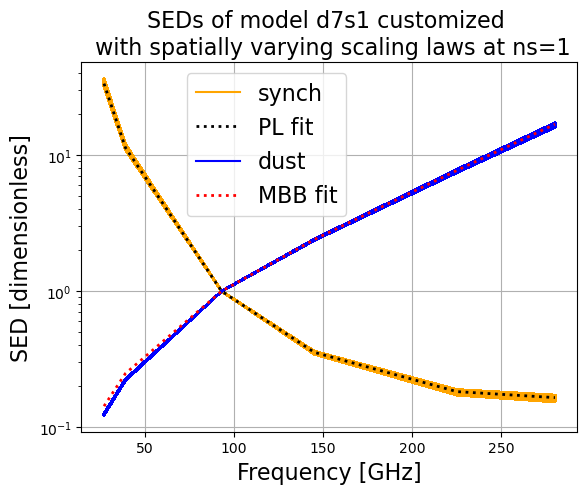

In [24]:
models = [['s1'], ['d7']]
cols = ['orange', 'blue']
if instr_name == 'LiteBIRD':
    ref_freqs = [9, 9]   #[0, -1]
elif instr_name == 'SO_SAT':
    ref_freqs = [2, 2]   #[0, -1]
labels = ['synch', 'dust']
stokes_idx = 1
# freq_maps_for_SEDs_reference = [freq_maps_s0, freq_maps_d0]

for i, model in enumerate(models):
    # get input freq maps customized with less spv of SEDs
    freq_maps_fgs_spvns1, mixing_mat_fgs_spvns1 = fgs_freq_maps_from_customized_model_nonparam(nside_map, nside_spv, instrument, fgs_models=model, idx_ref_freq=ref_freqs[0], return_mixing_mat=True)

    label_added = False
    for pix_idx, _ in enumerate(freq_maps_fgs_spvns1[0, 0, :]):
        if not label_added:
            plt.plot(instrument.frequency, freq_maps_fgs_spvns1[:, stokes_idx, pix_idx]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, pix_idx], color=cols[i], label=labels[i])
            label_added = True
        else:
            plt.plot(instrument.frequency, freq_maps_fgs_spvns1[:, stokes_idx, pix_idx]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, pix_idx], color=cols[i])

    # # reference MBB and PL (from d0)
    # plt.plot(instrument.frequency, freq_maps_for_SEDs_reference[i][:, stokes_idx, 0]/freq_maps_for_SEDs_reference[i][ref_freqs[i], stokes_idx, 0], color='black')  #, label='d0')

    # fit with MBB and PL
    ### Functions to do the fit 
    # (they are also imlemented in the init_mixingmatrix module,
    # but I put them here with small modifications to do the fit)
    h_over_k = constants.h * 1e9 / constants.k
    nu0 = instrument.frequency[ref_freqs[i]]

    def K_rj2K_cmb(nu):
        Tcmb = Planck15.Tcmb(0).value
        # Conversion factor at frequency nu
        K_rj2K_cmb = np.expm1(h_over_k * nu / Tcmb) ** 2 / (np.exp(h_over_k * nu / Tcmb) * (h_over_k * nu / Tcmb) ** 2)

        return K_rj2K_cmb

    def K_rj2K_cmb_nu0(nu):
        K_rj2K_cmb_nu0 = K_rj2K_cmb(nu) / K_rj2K_cmb(nu0)

        return K_rj2K_cmb_nu0

    def powerlaw(nu, beta_pl):
        analytic_expr = (nu / nu0) ** (beta_pl)
        # conversion to K_CMB units
        analytic_expr *= K_rj2K_cmb_nu0(nu)

        return analytic_expr

    def modifiedblackbody(nu, temp_mbb, beta_mbb):
        analytic_expr = (
            (np.exp(nu0 / temp_mbb * h_over_k) - 1)
            / (np.exp(nu / temp_mbb * h_over_k) - 1)
            * (nu / nu0) ** (1 + beta_mbb)
        )
        # conversion to K_CMB units
        analytic_expr *= K_rj2K_cmb_nu0(nu)

        return analytic_expr
    
    if i == 0:
        average_SED_synch = np.average(freq_maps_fgs_spvns1[:, stokes_idx, :]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, :], axis=1)
        beta_s_fit = sp.optimize.curve_fit(powerlaw, instrument.frequency, average_SED_synch, p0=[-3.0])[0][0]
        plt.plot(instrument.frequency, powerlaw(instrument.frequency, beta_s_fit), color='black', linestyle=':', linewidth=2.0, label='PL fit')
    elif i == 1:
        average_SED_dust = np.average(freq_maps_fgs_spvns1[:, stokes_idx, :]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, :], axis=1)
        T_d_fit, beta_d_fit = sp.optimize.curve_fit(modifiedblackbody, instrument.frequency, average_SED_dust, p0=[20., 1.54])[0]
        plt.plot(instrument.frequency, modifiedblackbody(instrument.frequency, T_d_fit, beta_d_fit), color='r', linestyle=':', linewidth=2.0, label='MBB fit')

plt.title('SEDs of model '+str(models[1][0])+str(models[0][0])+' customized \n with spatially varying scaling laws at ns=1',fontsize=16)
plt.ylabel('SED [dimensionless]', fontsize=16)
plt.xlabel('Frequency [GHz]', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=16, bbox_to_anchor=(.19, 1))
plt.grid()